# Pulsed Resonator Spectroscopy vs Power with SHFQA or SHFQC

This notebook shows you how to perform pulsed resonator spectroscopy vs power in LabOne Q with a SHFQA or the quantum analyzer channels of a SHFQC. Here, you'll find the perform a 2D sweep of the frequency vs power on the qubit readout resonator to find the optimal settings at which to drive it.

## 0. LabOne Q Imports

You'll begin by importing `laboneq.simple` and some extra helper functions to run the examples. 

In [1]:
import time
from pathlib import Path

# Helpers:
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results

# LabOne Q:
from laboneq.simple import *

## 1. Device Setup

Below, you'll create a device setup and choose to run this notebook in emulated mode or directly on the control hardware, by specifying `use_emulation = True/False` respectively.

If you run on your hardware, you need to generate a device setup first, please have a look at our [device setup tutorial](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/tutorials/00_device_setup.html) for how to do this in general.
Here, we use a helper functions to generate the device setup and a set up qubit objects with pre-defined parameters. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 6

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "options": None,
        }
    ],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    include_flux_lines=True,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_tunable_qubit_setup",
)

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.26 14:00:46.914] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 14:00:46.916] INFO    VERSION: laboneq 26.4.0
[2026.06.26 14:00:46.917] INFO    Connecting to data server at localhost:8004
[2026.06.26 14:00:46.918] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 14:00:46.919] INFO    Configuring the device setup
[2026.06.26 14:00:46.945] INFO    The device setup is configured


## 2. Experiment Parameters

Now you'll define the frequency sweep parameters, amplitude points, and pulse to use in your experiment.

In [4]:
# frequency range of spectroscopy scan -
# around expected centre frequency as defined in qubit parameters
start_freq = -500e6
stop_freq = 500e6
num_freq_points = 1001

# set number of points for amplitude sweep
num_amp_points = 21


# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )


# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4

# readout pulse parameters and definition
envelope_duration = 2.048e-6
envelope_rise_fall_time = 0.05e-6
readout_pulse = pulse_library.gaussian_square(
    uid="readout_pulse", length=envelope_duration, amplitude=0.9
)

## 3. Experiment Definition

 You'll now create a function which generates a resonator spectroscopy vs power [experiment](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/05_experiment/concepts/index.html). In this experiment, you'll pass the `LinearSweepParameter` defined previously as an argument to the [sweep section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/04_averaging_sweeping.html#parameter-sweeps), as well as make a near-time sweep outside the real-time acquisition loop which sweeps the gain node of the SHFQA. Within the real-time frequency sweep section, you'll create a [section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/index.html) containing a `play` and an `acquire` command.

In [5]:
def res_spectroscopy_pulsed_amp_sweep(
    frequency_sweep, amplitude_sweep, num_averages, readout_pulse
):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec_amp = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # outer, near-time loop - vary drive amplitude
    with exp_spec_amp.sweep(uid="res_amp", parameter=amplitude_sweep):
        # averaging loop
        with exp_spec_amp.acquire_loop_rt(
            uid="shots",
            count=2**num_averages,
            acquisition_type=AcquisitionType.SPECTROSCOPY,
        ):
            # inner, real-time loop - vary drive frequency
            with exp_spec_amp.sweep(uid="res_freq", parameter=frequency_sweep):
                # readout pulse and data acquisition
                with exp_spec_amp.section(uid="spectroscopy"):
                    # play resonator excitation pulse
                    exp_spec_amp.play(signal="measure", pulse=readout_pulse)
                    # resonator signal readout
                    exp_spec_amp.acquire(
                        signal="acquire",
                        handle="res_spec_pulsed",
                        length=envelope_duration,
                    )
                # relax time after readout - for signal processing and qubit relaxation to ground state
                with exp_spec_amp.section(uid="relax", length=1e-6):
                    exp_spec_amp.reserve(signal="measure")

    exp_calibration = Calibration()
    # for spectroscopy, set the sweep parameters for frequency and amplitude
    measure_acquire_oscillator = Oscillator(
        "readout_osc",
        frequency=frequency_sweep,
    )
    exp_calibration["measure"] = SignalCalibration(
        oscillator=measure_acquire_oscillator,
        amplitude=amplitude_sweep,
    )
    exp_calibration["acquire"] = SignalCalibration(
        oscillator=measure_acquire_oscillator,
    )
    exp_spec_amp.set_calibration(exp_calibration)

    return exp_spec_amp

### 3.1 Experiment Calibration and Signal Map

Before running the experiment, you'll need to set an [experiment calibration](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/05_experiment/concepts/00_experiment_calibration.html). The sweep parameter is assigned to the hardware oscillator modulating the readout resonator drive line. You'll also define and set the mapping between the experimental and logical lines.

In [6]:
# signal maps for the two different qubits - maps the logical signal of the device setup to the experimental signals of the experiment


def res_spec_map(qubit):
    signal_map = {
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


amplitude_sweep = LinearSweepParameter(
    uid="amp_sweep_param", start=0.1, stop=0.99, count=num_amp_points
)
frequency_sweep = create_readout_freq_sweep(
    "q0", start_freq, stop_freq, num_freq_points
)

exp_spec_amp = res_spectroscopy_pulsed_amp_sweep(
    frequency_sweep, amplitude_sweep, num_averages, readout_pulse
)
exp_spec_amp.set_signal_map(res_spec_map("q0"))

### 3.2 Compile and Generate Pulse Sheet

Now you'll compile the experiment and generate a pulse sheet.

In [7]:
# compile the experiment on the open instrument session
compiled_spec_amp = session.compile(exp_spec_amp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Spectroscopy_vs_Amplitude", compiled_spec_amp)

[2026.06.26 14:00:46.972] INFO    Starting LabOne Q Compiler run...
[2026.06.26 14:00:46.976] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Hardware
[2026.06.26 14:00:46.976] INFO    Resolved modulation type of oscillator on signal: 'measure' to Hardware
[2026.06.26 14:00:46.980] INFO    Schedule completed. [0.003 s]
[2026.06.26 14:00:46.998] INFO    Code generation completed for all AWGs. [0.018 s]
[2026.06.26 14:00:46.999] INFO    Completed compilation step 1 of 21. [0.022 s]
[2026.06.26 14:00:46.999] INFO    Skipping compilation for next step(s)...
[2026.06.26 14:00:47.002] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.26 14:00:47.003] INFO      Device    AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.26 14:00:47.003] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.26 14:00:47.003] INFO      shfqc_0     0         21            0           1      8192  
[2026.06.26 14:00:47.003]

/Users/khatran/Desktop/pico-thermometry/tune-up/Pulse_Sheets/Spectroscopy_vs_Amplitude_2026-06-26-14-00-47.html

### 3.3 Run, Save, and Plot Results

Finally, you'll run the experiment, save, and plot the results.

In [8]:
# run the compiled experiemnt
spec_amp_results = session.run(compiled_spec_amp)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(spec_amp_results, f"Results/{timestamp}_spec_amp_results.json")
print(f"File saved as Results/{timestamp}_spec_amp_results.json")

[2026.06.26 14:00:47.050] INFO    Starting near-time execution...
[2026.06.26 14:00:47.115] INFO    Finished near-time execution.
File saved as Results/20260626T140047_spec_amp_results.json


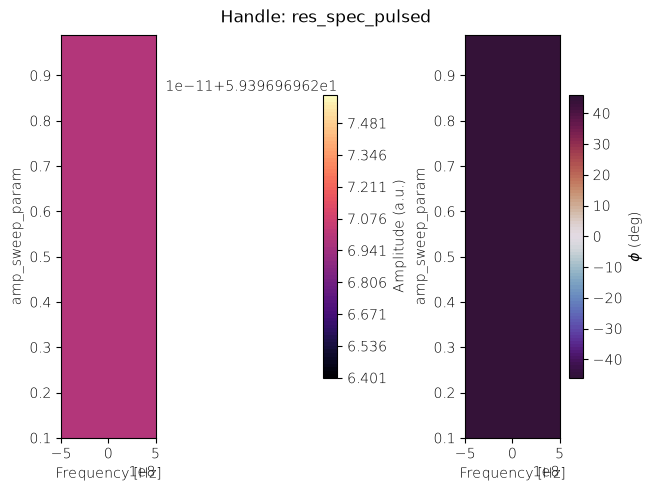

In [9]:
plot_results(spec_amp_results, phase=True)